In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

In [2]:
varname='wap'

In [3]:
# Tropical bounds
trop_lat_min = -30
trop_lat_max = 30

# Pressure level
target_plev = 50000  # 500 hPa in Pa

In [4]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    # "piControl": {"project": "CMIP",        "scenario": "piControl"},
    # "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    # "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    # "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


# Functions

In [5]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2099-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))



# PDF

In [5]:
# # ================================================================
# # MAIN PROCESSING LOOP - Tropical circulation metrics
# # Following Bony et al. (2013) for tropical overturning circulation
# # ================================================================

# import pandas as pd
# import xarray as xr
# import numpy as np

# var = {}
# var_by_year = {}
# data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}
# all_results = {}
# counts_all = {}

# # Tropical bounds
# trop_lat_min = -30
# trop_lat_max = 30

# all_values = []

# # Pressure level
# target_plev = 50000  # 500 hPa in Pa

# for model_name, model_meta in MODELS.items():

#     counts_all[model_name] = {}
#     components_by_exp = {}
#     seasonal_data = {}

#     # ----------------------------
#     # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#     # ----------------------------
#     for exp, meta in EXPERIMENTS.items():

#         # --- special-case ensemble override ---
#         if model_name == "CESM2-WACCM":
#             ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#         else:
#             ensemble = model_meta["ensemble"]

#         def make_base(vname):
#             return (
#                 CEDA_BASE
#                 / meta["project"]
#                 / model_meta["institution"]
#                 / model_name
#                 / meta["scenario"]
#                 / ensemble
#                 / "Amon"
#                 / vname
#                 / model_meta["grid"]
#                 / "latest"
#             )

#         base_wap = make_base("wap")
        
#         ####### Handle ALTERNATE base paths ######
#         ds_wap = load_model_data_alt_path(base_wap, meta["project"], 
#                                           model_meta["institution"], 
#                                           model_name, meta["scenario"], 
#                                           ensemble, model_meta["grid"], mf, "wap")
        
#         # Roll and regrid (regridded to 2.5x2.5)
#         ds_wap = roll_and_regrid(ds_wap)
        
#         print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
#               f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

#         # Extract omega (wap) variable
#         if isinstance(ds_wap, xr.Dataset):
#             omega = ds_wap['wap']
#         else:
#             omega = ds_wap
        
#         # Select 500 hPa level and tropical region
#         omega_500 = omega.sel(plev=target_plev, method='nearest')
#         omega_trop = omega_500.sel(lat=slice(trop_lat_min, trop_lat_max))
        
#         # var[exp] = omega_trop

#         values = omega_trop.values.flatten()
#         values = values[np.isfinite(values)]
#         all_values.append(values)

# all_values = np.concatenate(all_values)

# vmin = float(np.nanpercentile(all_values, 2))
# vmax = float(np.nanpercentile(all_values, 98))

# nbins = 50
# bin_edges_ref = np.linspace(vmin, vmax, nbins + 1)

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /home/users/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /home/users/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-

In [6]:
# ================================================================
# MAIN PROCESSING LOOP - Tropical circulation metrics
# Following Bony et al. (2013) for tropical overturning circulation
# ================================================================

import pandas as pd
import xarray as xr
import numpy as np

var = {}
var_by_year = {}
data_by_experiment = {exp: [] for exp in EXPERIMENTS.keys()}
all_results = {}
# counts_all = {}

# Tropical bounds
trop_lat_min = -30
trop_lat_max = 30

# Pressure level
target_plev = 50000  # 500 hPa in Pa

for model_name, model_meta in MODELS.items():

    counts_all[model_name] = {}
    components_by_exp = {}
    seasonal_data = {}

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():

        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")
        
        ####### Handle ALTERNATE base paths ######
        ds_wap = load_model_data_alt_path(base_wap, meta["project"], 
                                          model_meta["institution"], 
                                          model_name, meta["scenario"], 
                                          ensemble, model_meta["grid"], mf, "wap")
        
        # Roll and regrid (regridded to 2.5x2.5)
        ds_wap = roll_and_regrid(ds_wap)
        
        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        # Extract omega (wap) variable
        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap
        
        # Select 500 hPa level and tropical region
        omega_500 = omega.sel(plev=target_plev, method='nearest')
        omega_trop = omega_500.sel(lat=slice(trop_lat_min, trop_lat_max))
        
        # var[exp] = omega_trop

        values = omega_trop.values.flatten()
        values = values[np.isfinite(values)]

        # v1 = float(np.nanpercentile((values), 98))
        # v2 = float(np.nanpercentile((values), 2))
        # vmin, vmax = min(v1, v2), max(v1, v2)
        # width=(vmax-vmin)/50
        # bin_edges_ref = np.arange(vmin, vmax, width)

        
        counts, _ = np.histogram(values, bins=bin_edges_ref)
        percent = 100 * counts / counts.sum()


        # --- STORE ---
        counts_all[model_name][exp] = {
            "counts": counts,
            "percent": percent,
            "bin_edges": bin_edges_ref,
        }

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 1032 months (2015-01-16 00:00:00 → 2100-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /home/users/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /home/users/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 1032 months (2015-01-16 12:00:00 → 2100-12-16 12:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-

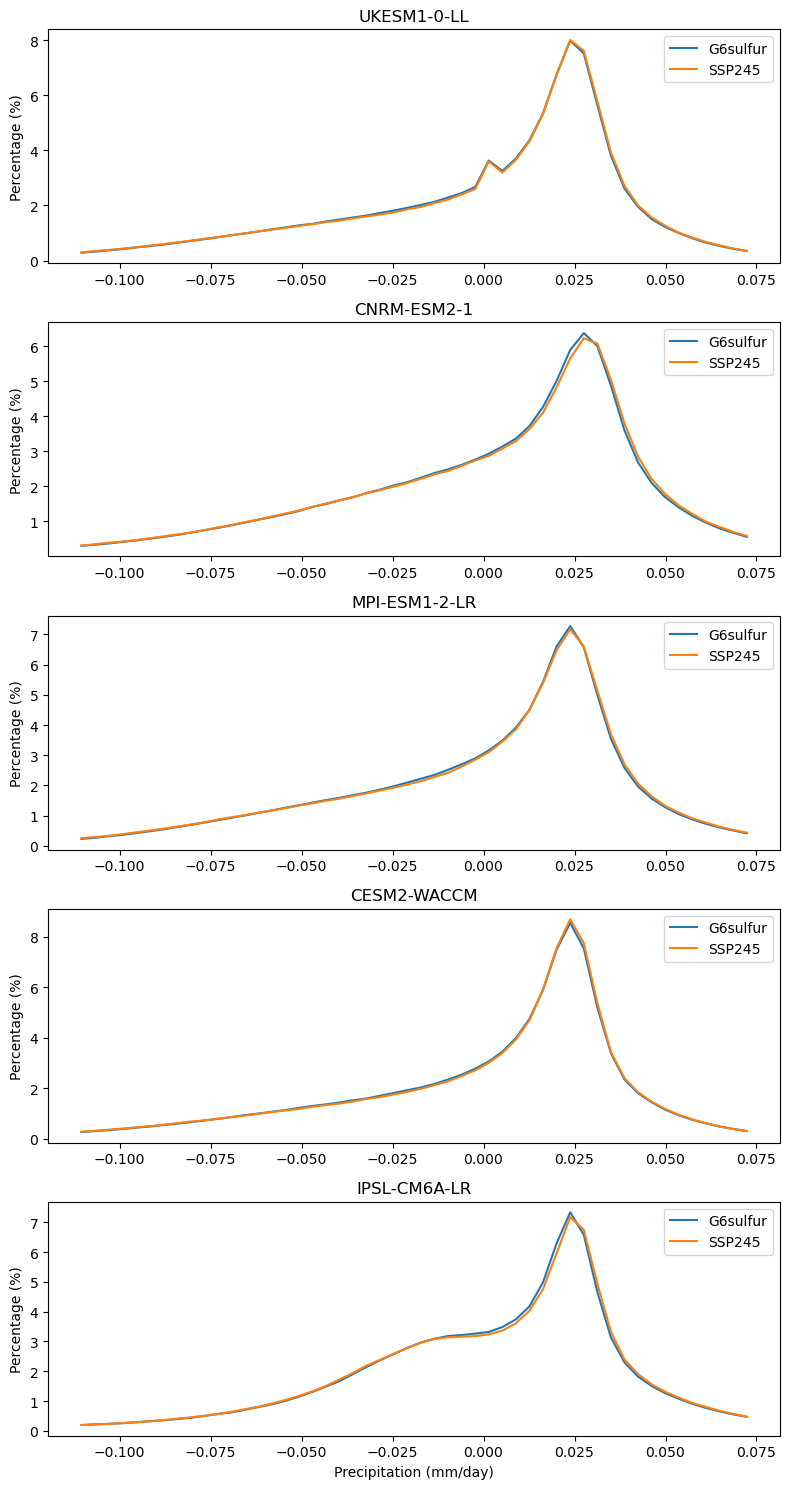

In [7]:
fig, axes = plt.subplots(
    nrows=len(counts_all),
    ncols=1,
    figsize=(8, 3 * len(counts_all)),
)

axes = np.atleast_1d(axes)

for row, model in enumerate(counts_all):

    for exp in counts_all[model]:

        percent = counts_all[model][exp]["percent"]
        edges = counts_all[model][exp]["bin_edges"]
        centers = 0.5 * (edges[:-1] + edges[1:])

        axes[row].plot(centers, percent, label=exp)

    axes[row].set_title(model)
    axes[-1].set_xlabel("Precipitation (mm/day)")
    axes[row].set_ylabel("Percentage (%)")
    axes[row].legend()

plt.tight_layout()

plt.show()

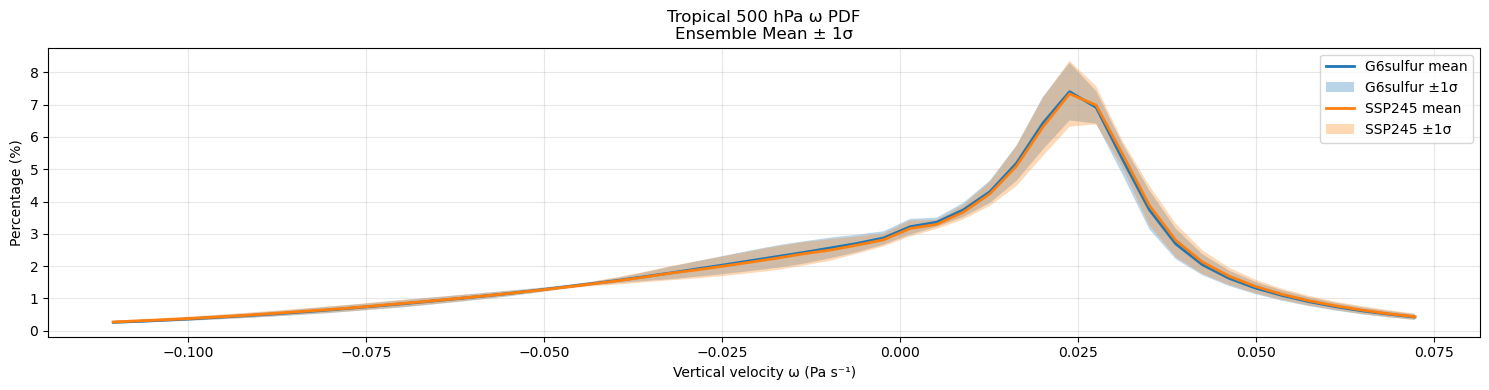

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 4))

for exp in EXPERIMENTS.keys():

    all_percent = []
    centers_ref = None

    for model in counts_all.keys():

        percent = counts_all[model][exp]["percent"]
        edges = counts_all[model][exp]["bin_edges"]
        centers = 0.5 * (edges[:-1] + edges[1:])

        if centers_ref is None:
            centers_ref = centers  # use first model as reference

        all_percent.append(percent)

    # Stack models → shape (n_models, n_bins)
    all_percent = np.array(all_percent)

    # Ensemble statistics
    mean_percent = np.nanmean(all_percent, axis=0)
    std_percent  = np.nanstd(all_percent, axis=0)

    # Plot ensemble mean
    ax.plot(
        centers_ref,
        mean_percent,
        label=f"{exp} mean",
        linewidth=2,
    )

    # Spread (±1 std)
    ax.fill_between(
        centers_ref,
        mean_percent - std_percent,
        mean_percent + std_percent,
        alpha=0.3,
        label=f"{exp} ±1σ",
        # color=exp.get("color", None)
    )

ax.set_xlabel("Vertical velocity ω (Pa s⁻¹)")
ax.set_ylabel("Percentage (%)")
ax.set_title("Tropical 500 hPa ω PDF\nEnsemble Mean ± 1σ")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

#Saving figure
fig_directory='/home/users/bidyut/UoE/20260218_Monsoons'
figname="Figure_PDF_w500_2021-2100"

# plt.savefig(''+str(fig_directory)+'/'+str(figname)+'.svg', format="svg",transparent=True, dpi=1200)
# !rsvg-convert -f pdf -o {fig_directory}/{figname}.pdf {fig_directory}/{figname}.svg

plt.savefig(''+str(fig_directory)+'/'+str(figname)+'.pdf', format="pdf")

plt.show()

# Scatter plot

/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 948 months
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 948 months
  [UKESM1-0-LL] Valid points: 1275097
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 948 months
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 948 months
  [CNRM-ESM2-1] Valid points: 1355256
/badc/cmip6/data/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp245/r1i1p1f1/Amon/wap/gn/latest
Alt path is: /gws/ssde/j25b/impose/bid

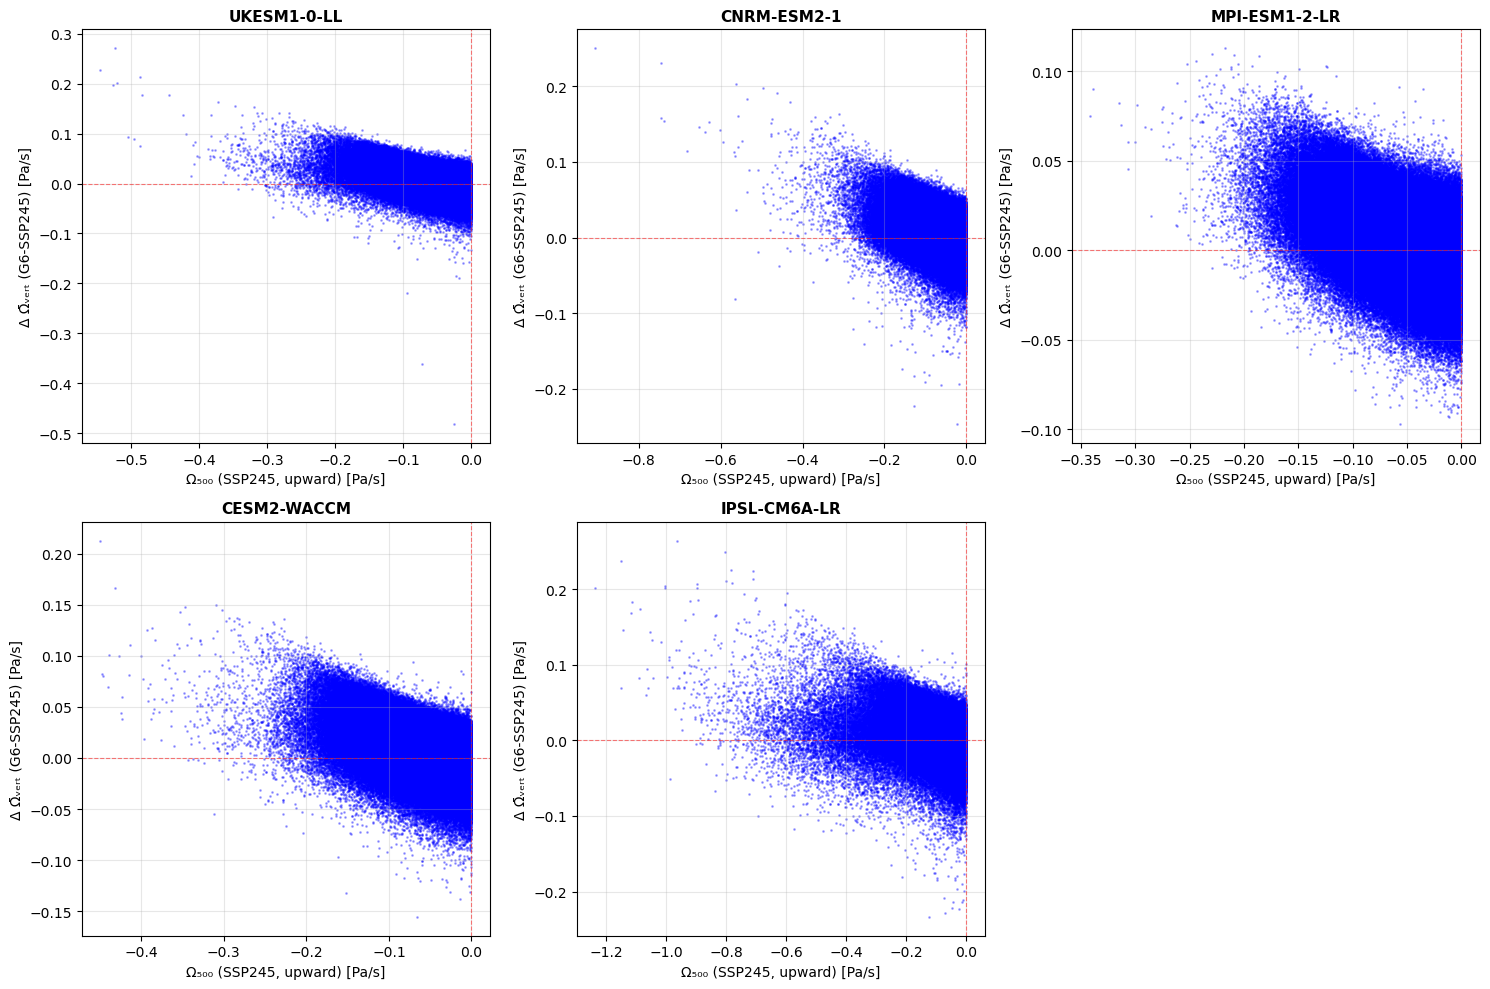

In [28]:
# ================================================================
# SCATTER ANALYSIS - Omega500_up vs delta_VerticallyAveragedOmega_up
# ================================================================
import matplotlib.pyplot as plt

scatter_data = {}

for model_name, model_meta in MODELS.items():
    scatter_data[model_name] = {}
    
    # ----------------------------
    # 1) LOAD DATA FOR BOTH EXPERIMENTS
    # ----------------------------
    omega_data = {}
    
    for exp in ['SSP245', 'G6sulfur']:
        meta = EXPERIMENTS[exp]
        
        # --- special-case ensemble override ---
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]
        
        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )
        
        base_wap = make_base("wap")
        
        # Load data
        ds_wap = load_model_data_alt_path(base_wap, meta["project"], 
                                          model_meta["institution"], 
                                          model_name, meta["scenario"], 
                                          ensemble, model_meta["grid"], mf, "wap")

        #Slice
        t_start, t_end = _time_slice(exp)
        ds_wap = ds_wap.sel(time=slice(t_start, t_end))
        
        # Roll and regrid
        ds_wap = roll_and_regrid(ds_wap)
        
        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months")
        
        # Extract omega variable
        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap
        
        # Select tropical region
        omega_trop = omega.sel(lat=slice(trop_lat_min, trop_lat_max))
        
        omega_data[exp] = omega_trop
    
    # ----------------------------
    # 2) COMPUTE METRICS
    # ----------------------------
    
    # SSP245: Omega at 500 hPa (upward only - negative values)
    omega_500_ssp = omega_data['SSP245'].sel(plev=target_plev, method='nearest')
    
    # Create mask for upward motion (omega < 0) at 500 hPa in SSP245
    upward_mask = omega_500_ssp < 0
    
    # Get the upward omega values at 500 hPa for SSP245
    omega_500_up_ssp = omega_500_ssp.where(upward_mask)
    
    # ----------------------------
    # 3) VERTICALLY AVERAGED OMEGA (all pressure levels)
    # ----------------------------
    
    # Vertically average omega for SSP245 (weighted by pressure)
    # Use all available pressure levels
    # plev_weights = omega_data['SSP245'].plev / omega_data['SSP245'].plev.sum()
    # omega_vert_avg_ssp = (omega_data['SSP245'] * plev_weights).sum(dim='plev')
    omega_vert_avg_ssp = omega_data['SSP245'].mean(dim='plev')
    
    # Vertically average omega for G6sulfur
    # plev_weights_g6 = omega_data['G6sulfur'].plev / omega_data['G6sulfur'].plev.sum()
    # omega_vert_avg_g6 = (omega_data['G6sulfur'] * plev_weights_g6).sum(dim='plev')
    omega_vert_avg_g6 = omega_data['G6sulfur'].mean(dim='plev')
    
    
    # Delta: G6sulfur - SSP245 (vertically averaged)
    delta_omega_vert_avg = omega_vert_avg_g6 - omega_vert_avg_ssp
    
    # Extract delta only at points where SSP245 has upward motion at 500 hPa
    delta_omega_up = delta_omega_vert_avg.where(upward_mask)
    
    # ----------------------------
    # 4) FLATTEN FOR SCATTER PLOT
    # ----------------------------
    
    # Flatten arrays and remove NaNs
    x_vals = omega_500_up_ssp.values.flatten()
    y_vals = delta_omega_up.values.flatten()
    
    # Remove NaN/inf values
    valid_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_clean = x_vals[valid_mask]
    y_clean = y_vals[valid_mask]
    
    scatter_data[model_name] = {
        'x': x_clean,
        'y': y_clean
    }
    
    print(f"  [{model_name}] Valid points: {len(x_clean)}")

# ----------------------------
# 5) CREATE SCATTER PLOT
# ----------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, data) in enumerate(scatter_data.items()):
    ax = axes[idx]
    
    # Create scatter plot with transparency
    ax.scatter(data['x'], data['y'], alpha=0.3, s=1, c='blue')
    
    # Add zero lines for reference
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Labels and title
    ax.set_xlabel('Ω₅₀₀ (SSP245, upward) [Pa/s]', fontsize=10)
    ax.set_ylabel('Δ Ω̄ᵥₑᵣₜ (G6-SSP245) [Pa/s]', fontsize=10)
    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove empty subplots if fewer than 6 models
for idx in range(len(scatter_data), 6):
    fig.delaxes(axes[idx])

plt.tight_layout()
# plt.savefig('scatter_omega500_vs_delta_vertavg.png', dpi=300, bbox_inches='tight')
plt.show()

# print("\nScatter plot saved!")

/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/Scena

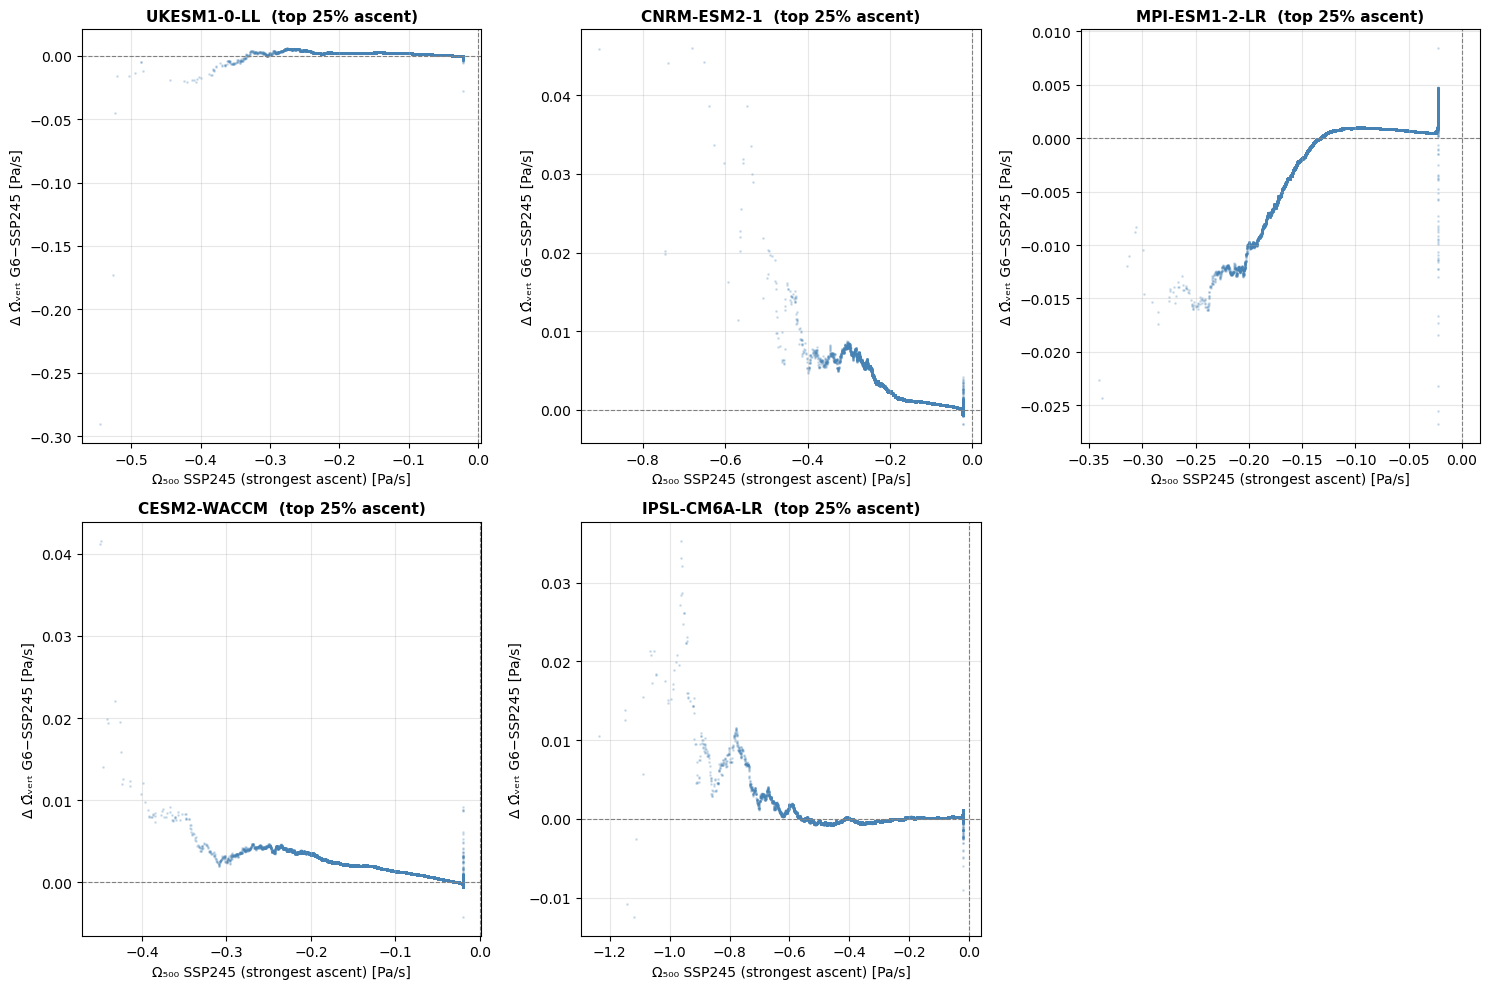

In [23]:
# ================================================================
# SCATTER - Independently sorted ascent regions (0-25th percentile)
# ================================================================

ascent_percentile = 25

# ----------------------------
# 1) LOAD AND STORE ALL DATA
# ----------------------------
omega_store = {}

for model_name, model_meta in MODELS.items():
    omega_store[model_name] = {}

    for exp in ['SSP245', 'G6sulfur']:
        meta = EXPERIMENTS[exp]

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")

        ds_wap = load_model_data_alt_path(base_wap, meta["project"],
                                          model_meta["institution"],
                                          model_name, meta["scenario"],
                                          ensemble, model_meta["grid"], mf, "wap")

        # Time slice
        t_start, t_end = _time_slice(exp)
        ds_wap = ds_wap.sel(time=slice(t_start, t_end))

        # Roll and regrid
        ds_wap = roll_and_regrid(ds_wap)

        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap

        # Tropical region only
        omega_trop = omega.sel(lat=slice(trop_lat_min, trop_lat_max))

        # Store
        omega_store[model_name][exp] = omega_trop

# ----------------------------
# 2) COMPUTE AND PLOT
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, exps) in enumerate(omega_store.items()):
    ax = axes[idx]

    omega_ssp = exps['SSP245']    # (time, plev, lat, lon)
    omega_g6  = exps['G6sulfur']  # (time, plev, lat, lon)

    # --- SSP245: mask by its own omega500 threshold ---
    omega_500_ssp = omega_ssp.sel(plev=target_plev, method='nearest')
    thresh_ssp    = float(np.nanpercentile(omega_500_ssp.values, ascent_percentile))
    mask_ssp      = omega_500_ssp < thresh_ssp   # strongest ascent in SSP245

    # Vertically averaged omega for SSP245 at SSP245's ascent points
    # plev_w_ssp       = omega_ssp.plev / omega_ssp.plev.sum()
    # vert_avg_ssp     = (omega_ssp * plev_w_ssp).sum(dim='plev')
    vert_avg_ssp     =  omega_ssp.mean(dim='plev')
    vert_avg_ssp_asc = vert_avg_ssp.where(mask_ssp)

    x_vals = omega_500_ssp.where(mask_ssp).values.flatten()
    y_ssp  = vert_avg_ssp_asc.values.flatten()

    # --- G6sulfur: mask by its OWN omega500 threshold ---
    omega_500_g6 = omega_g6.sel(plev=target_plev, method='nearest')
    thresh_g6    = float(np.nanpercentile(omega_500_g6.values, ascent_percentile))
    mask_g6      = omega_500_g6 < thresh_g6   # strongest ascent in G6sulfur

    # Vertically averaged omega for G6sulfur at G6's own ascent points
    # plev_w_g6       = omega_g6.plev / omega_g6.plev.sum()
    # vert_avg_g6     = (omega_g6 * plev_w_g6).sum(dim='plev')
    vert_avg_g6     = omega_g6.mean(dim='plev')
    vert_avg_g6_asc = vert_avg_g6.where(mask_g6)

    y_g6 = vert_avg_g6_asc.values.flatten()

    # --- Pair by rank (sort independently, then pair) ---
    x_clean     = np.sort(x_vals[np.isfinite(x_vals)])
    y_ssp_clean = np.sort(y_ssp[np.isfinite(y_ssp)])
    y_g6_clean  = np.sort(y_g6[np.isfinite(y_g6)])

    n       = min(len(x_clean), len(y_ssp_clean), len(y_g6_clean))
    x_plot  = x_clean[:n]
    delta_y = y_g6_clean[:n] - y_ssp_clean[:n]

    # --- Plot ---
    ax.scatter(x_plot, delta_y, alpha=0.2, s=1, c='steelblue')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Ω₅₀₀ SSP245 (strongest ascent) [Pa/s]', fontsize=10)
    ax.set_ylabel('Δ Ω̄ᵥₑᵣₜ G6−SSP245 [Pa/s]', fontsize=10)
    ax.set_title(f'{model_name}  (top {ascent_percentile}% ascent)',
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

for idx in range(len(omega_store), 6):
    fig.delaxes(axes[idx])

plt.tight_layout()
# plt.savefig('scatter_independent_ascent.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ================================================================
# SCATTER - Independently sorted ascent regions (0-25th percentile)
# Compute and store results for later plotting
# ================================================================

ascent_percentile = 25

# ----------------------------
# 1) LOAD AND STORE ALL DATA
# ----------------------------
omega_store = {}

for model_name, model_meta in MODELS.items():
    omega_store[model_name] = {}

    for exp in ['SSP245', 'G6sulfur']:
        meta = EXPERIMENTS[exp]

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")

        ds_wap = load_model_data_alt_path(base_wap, meta["project"],
                                          model_meta["institution"],
                                          model_name, meta["scenario"],
                                          ensemble, model_meta["grid"], mf, "wap")

        t_start, t_end = _time_slice(exp)
        ds_wap = ds_wap.sel(time=slice(t_start, t_end))
        ds_wap = roll_and_regrid(ds_wap)

        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap

        omega_store[model_name][exp] = omega.sel(lat=slice(trop_lat_min, trop_lat_max))

# ----------------------------
# 2) COMPUTE AND STORE RESULTS
# ----------------------------
all_results = {}   # all_results[model_name] = dict of arrays for plotting

for model_name, exps in omega_store.items():

    omega_ssp = exps['SSP245']
    omega_g6  = exps['G6sulfur']

    # --- SSP245: mask by its own omega500 threshold ---
    omega_500_ssp = omega_ssp.sel(plev=target_plev, method='nearest')
    thresh_ssp    = float(np.nanpercentile(omega_500_ssp.values, ascent_percentile))
    mask_ssp      = omega_500_ssp < thresh_ssp

    plev_w_ssp       = omega_ssp.plev / omega_ssp.plev.sum()
    vert_avg_ssp     = (omega_ssp * plev_w_ssp).sum(dim='plev')
    vert_avg_ssp_asc = vert_avg_ssp.where(mask_ssp)

    x_vals = omega_500_ssp.where(mask_ssp).values.flatten()
    y_ssp  = vert_avg_ssp_asc.values.flatten()

    # --- G6sulfur: mask by its OWN omega500 threshold ---
    omega_500_g6 = omega_g6.sel(plev=target_plev, method='nearest')
    thresh_g6    = float(np.nanpercentile(omega_500_g6.values, ascent_percentile))
    mask_g6      = omega_500_g6 < thresh_g6

    plev_w_g6       = omega_g6.plev / omega_g6.plev.sum()
    vert_avg_g6     = (omega_g6 * plev_w_g6).sum(dim='plev')
    vert_avg_g6_asc = vert_avg_g6.where(mask_g6)

    y_g6 = vert_avg_g6_asc.values.flatten()

    # --- Pair by rank ---
    x_clean     = np.sort(x_vals[np.isfinite(x_vals)])
    y_ssp_clean = np.sort(y_ssp[np.isfinite(y_ssp)])
    y_g6_clean  = np.sort(y_g6[np.isfinite(y_g6)])

    n = min(len(x_clean), len(y_ssp_clean), len(y_g6_clean))

    x_plot  = x_clean[:n]
    delta_y = y_g6_clean[:n] - y_ssp_clean[:n]

    all_results[model_name] = {
        'x':           x_plot,          # omega500 SSP245 at ascent points (sorted)
        'delta_y':     delta_y,          # vert_avg_G6(ascent) - vert_avg_SSP245(ascent)
        'y_ssp':       y_ssp_clean[:n], # vert_avg SSP245 at its own ascent points
        'y_g6':        y_g6_clean[:n],  # vert_avg G6sulfur at its own ascent points
        'thresh_ssp':  thresh_ssp,       # omega500 threshold used for SSP245
        'thresh_g6':   thresh_g6,        # omega500 threshold used for G6sulfur
        'n_points':    n,
    }

    print(f"  [{model_name}] stored {n} ascent points | "
          f"thresh_ssp={thresh_ssp:.4f}  thresh_g6={thresh_g6:.4f}")

print(f"\nDone. all_results keys: {list(all_results.keys())}")

/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/Scena

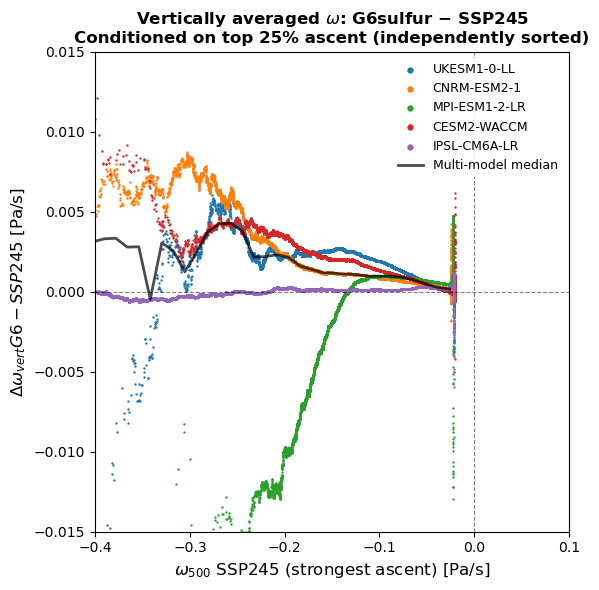

In [34]:
# ================================================================
# PLOT all_results - individual models + MMM + spread
# ================================================================

# --- Bin x-axis for ensemble mean/spread ---
n_bins     = 100
x_all      = np.concatenate([v['x'] for v in all_results.values()])
x_bin_edges = np.linspace(x_all.min(), x_all.max(), n_bins + 1)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])

# For each model, bin delta_y onto the common x-axis
model_binned = {}
for model_name, res in all_results.items():
    binned = np.full(n_bins, np.nan)
    for i in range(n_bins):
        lo, hi = x_bin_edges[i], x_bin_edges[i + 1]
        mask = (res['x'] >= lo) & (res['x'] < hi)
        if mask.sum() > 0:
            binned[i] = np.nanmean(res['delta_y'][mask])
    model_binned[model_name] = binned

# Stack for ensemble statistics
binned_stack = np.vstack(list(model_binned.values()))   # (n_models, n_bins)
# mmm          = np.nanmean(binned_stack, axis=0)
mmm          = np.nanmedian(binned_stack, axis=0)
spread_lo    = np.nanmin(binned_stack,  axis=0)
spread_hi    = np.nanmax(binned_stack,  axis=0)

# --- Colors per model ---
cmap   = plt.cm.tab10
colors = {name: cmap(i) for i, name in enumerate(all_results.keys())}

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

# Individual model scatter (tiny dots)
for model_name, res in all_results.items():
    ax.scatter(res['x'], res['delta_y'],
               s=0.5, alpha=1.0, color=colors[model_name], label=model_name)

# # Model spread (min–max across models, per bin)
# ax.fill_between(x_bin_centers, spread_lo, spread_hi,
#                 color='gray', alpha=0.25, label='Model spread (min–max)')

# Individual model binned means (slightly thicker, coloured)
for model_name, binned in model_binned.items():
    valid = np.isfinite(binned)
    ax.plot(x_bin_centers[valid], binned[valid],
            color=colors[model_name], linewidth=0.0, alpha=0.7, label='_nolegend_')

# Multi-model mean (thick black)
valid_mmm = np.isfinite(mmm)
ax.plot(x_bin_centers[valid_mmm], mmm[valid_mmm],
        color='k', linewidth=2, alpha=0.7, label='Multi-model median', zorder=15)

# Reference lines
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel('$\omega_{500}$ SSP245 (strongest ascent) [Pa/s]', fontsize=12)
ax.set_ylabel('$\Delta \omega_{vert} G6−SSP245$ [Pa/s]', fontsize=12)
ax.set_title(f'Vertically averaged $\omega$: G6sulfur − SSP245\n'
             f'Conditioned on top {ascent_percentile}% ascent (independently sorted)',
             fontsize=12, fontweight='bold')

ax.set_ylim(-0.015,0.015)
ax.set_xlim(-0.4,0.1)

ax.legend(loc='upper right', fontsize=9, markerscale=5,
          framealpha=0.9, edgecolor='none')
# ax.grid(True, alpha=0.3)
ax.grid(False)

plt.tight_layout()
# plt.savefig('scatter_mmm_spread.png', dpi=300, bbox_inches='tight')
plt.show()

# $\alpha$ calculation 

In [9]:
# ================================================================
# COMPUTE w500 tropical mean for each model and experiment
# alpha = delta_w500_tropicalmean / w500_tropicalmean_ssp245
# ================================================================

all_results = {}

for model_name, model_meta in MODELS.items():

    omega_store_model = {}

    for exp, meta in EXPERIMENTS.items():

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")

        ds_wap = load_model_data_alt_path(base_wap, meta["project"],
                                          model_meta["institution"],
                                          model_name, meta["scenario"],
                                          ensemble, model_meta["grid"], mf, "wap")

        t_start, t_end = _time_slice(exp)
        ds_wap = ds_wap.sel(time=slice(t_start, t_end))
        ds_wap = roll_and_regrid(ds_wap)

        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap

        # Select 500 hPa and tropical region
        omega_500  = omega.sel(plev=target_plev, method='nearest')
        omega_trop = omega_500.sel(lat=slice(trop_lat_min, trop_lat_max))

        # Tropical mean: area-weighted (cos-lat) mean over lat/lon, then time mean
        weights    = np.cos(np.deg2rad(omega_trop.lat))
        omega_mean = omega_trop.weighted(weights).mean(dim=['lat', 'lon'])  # (time,)

        omega_store_model[exp] = omega_mean  # time series of tropical mean w500

    # --- Compute alpha ---
    w500_ssp = omega_store_model[EXP2]   # e.g. SSP245, shape (time,)
    w500_g6  = omega_store_model[EXP1]   # e.g. G6sulfur, shape (time,)

    # Align time if needed
    common_time  = np.intersect1d(w500_ssp.time.values, w500_g6.time.values)
    w500_ssp_com = w500_ssp.sel(time=common_time)
    w500_g6_com  = w500_g6.sel(time=common_time)

    delta_w500   = w500_g6_com  - w500_ssp_com          # delta, shape (time,)

    # Time-mean scalars for alpha
    w500_ssp_mean   = float(w500_ssp_com.mean())
    w500_g6_mean    = float(w500_g6_com.mean())
    delta_w500_mean = float(delta_w500.mean())
    alpha           = delta_w500_mean / w500_ssp_mean

    all_results[model_name] = {
        'w500_ssp_timeseries':   w500_ssp_com,       # (time,) xarray
        'w500_g6_timeseries':    w500_g6_com,         # (time,) xarray
        'delta_w500_timeseries': delta_w500,           # (time,) xarray
        'w500_ssp_mean':         w500_ssp_mean,        # scalar
        'w500_g6_mean':          w500_g6_mean,         # scalar
        'delta_w500_mean':       delta_w500_mean,      # scalar
        'alpha':                 alpha,                 # scalar
    }

    print(f"  [{model_name}] w500_ssp={w500_ssp_mean:.4f}  "
          f"w500_g6={w500_g6_mean:.4f}  "
          f"delta={delta_w500_mean:.4f}  alpha={alpha:.4f}")

print("\nDone. all_results keys:", list(all_results.keys()))

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
  [UKESM1-0-LL] w500_ssp=-0.0001  w500_g6=-0.0002  delta=-0.0001  alpha=1.1535
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 948 

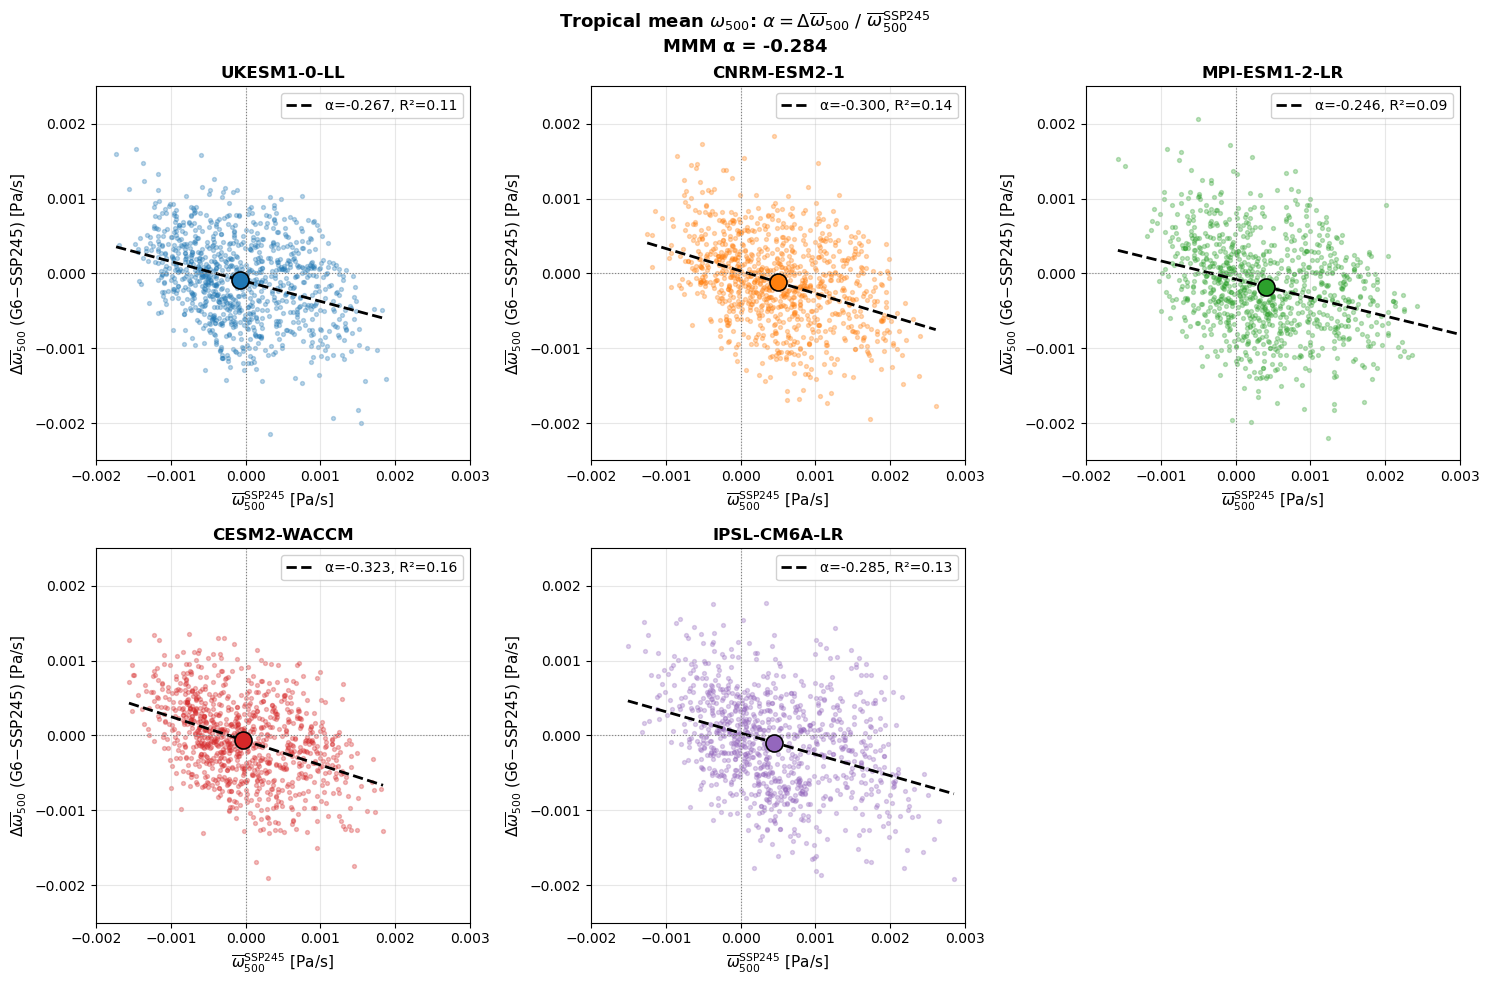


MMM α  = -0.2842
Per-model α (OLS) vs α (ratio of means):
  UKESM1-0-LL:  α_OLS=-0.2667   α_ratio=1.1535   R²=0.113
  CNRM-ESM2-1:  α_OLS=-0.3004   α_ratio=-0.2365   R²=0.140
  MPI-ESM1-2-LR:  α_OLS=-0.2456   α_ratio=-0.4396   R²=0.090
  CESM2-WACCM:  α_OLS=-0.3232   α_ratio=2.0653   R²=0.163
  IPSL-CM6A-LR:  α_OLS=-0.2850   α_ratio=-0.2136   R²=0.125


In [14]:
# ================================================================
# PLOT: scatter of delta_w500_tropicalmean vs w500_tropicalmean_SSP245
# one dot per time step per model, alpha shown per model
# ================================================================

from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, res) in enumerate(all_results.items()):
    ax     = axes[idx]
    color  = colors[model_name]

    x = res['w500_ssp_timeseries'].values
    y = res['delta_w500_timeseries'].values

    # --- Correct slope: OLS regression (no forced intercept) ---
    slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
    alpha_ols = slope   # this is the proper alpha

    # Update stored alpha too
    all_results[model_name]['alpha_ols'] = alpha_ols
    all_results[model_name]['r2']        = r_value**2

    # --- Plot ---
    ax.scatter(x, y, color=color, s=8, alpha=0.3)

    # Regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=2, linestyle='--',
            label=f'α={alpha_ols:.3f}, R²={r_value**2:.2f}')

    # Time-mean dot
    ax.scatter(res['w500_ssp_mean'], res['delta_w500_mean'],
               color=color, s=150, edgecolors='k', linewidths=1.2, zorder=5)

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)

    ax.set_xlabel(r'$\overline{\omega}_{500}^{\mathrm{SSP245}}$ [Pa/s]', fontsize=11)
    ax.set_ylabel(r'$\Delta\overline{\omega}_{500}$ (G6−SSP245) [Pa/s]', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.002,0.003)
    ax.set_ylim(-0.0025,0.0025)

# Hide unused panel
for idx in range(len(all_results), 6):
    axes[idx].axis('off')

# --- MMM alpha from OLS slopes ---
alpha_mmm_ols = np.mean([res['alpha_ols'] for res in all_results.values()])
fig.suptitle(rf'Tropical mean $\omega_{{500}}$: $\alpha = \Delta\overline{{\omega}}_{{500}}\ /\ \overline{{\omega}}_{{500}}^{{\mathrm{{SSP245}}}}$'
             f'\nMMM α = {alpha_mmm_ols:.3f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('scatter_alpha_w500_panels.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMMM α  = {alpha_mmm_ols:.4f}")
print("Per-model α (OLS) vs α (ratio of means):")
for m, res in all_results.items():
    print(f"  {m}:  α_OLS={res['alpha_ols']:.4f}   α_ratio={res['alpha']:.4f}   R²={res['r2']:.3f}")

/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] SSP245: wap loaded 948 months (2021-01-16 00:00:00 → 2099-12-16 00:00:00)
  [UKESM1-0-LL] alpha(OLS)=-0.0423  R²=0.222  n_points=3600
/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
Alt path is: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  → Using downloaded files at: /gws/ssde/j25b/impose/bidyut/data/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] G6sulfur: wap loaded 948 months (2021-01-16 12:00:00 → 2099-12-16 12:00:00)
/badc/cmip6/data/CMIP6/ScenarioMIP/CNRM-CERFACS/CNRM-ESM2-1/ssp245/r1i1p1f2/Amon/wap/gr/latest
  [CNRM-ESM2-1] SSP245: wap loaded 948 months (2021-01-16 

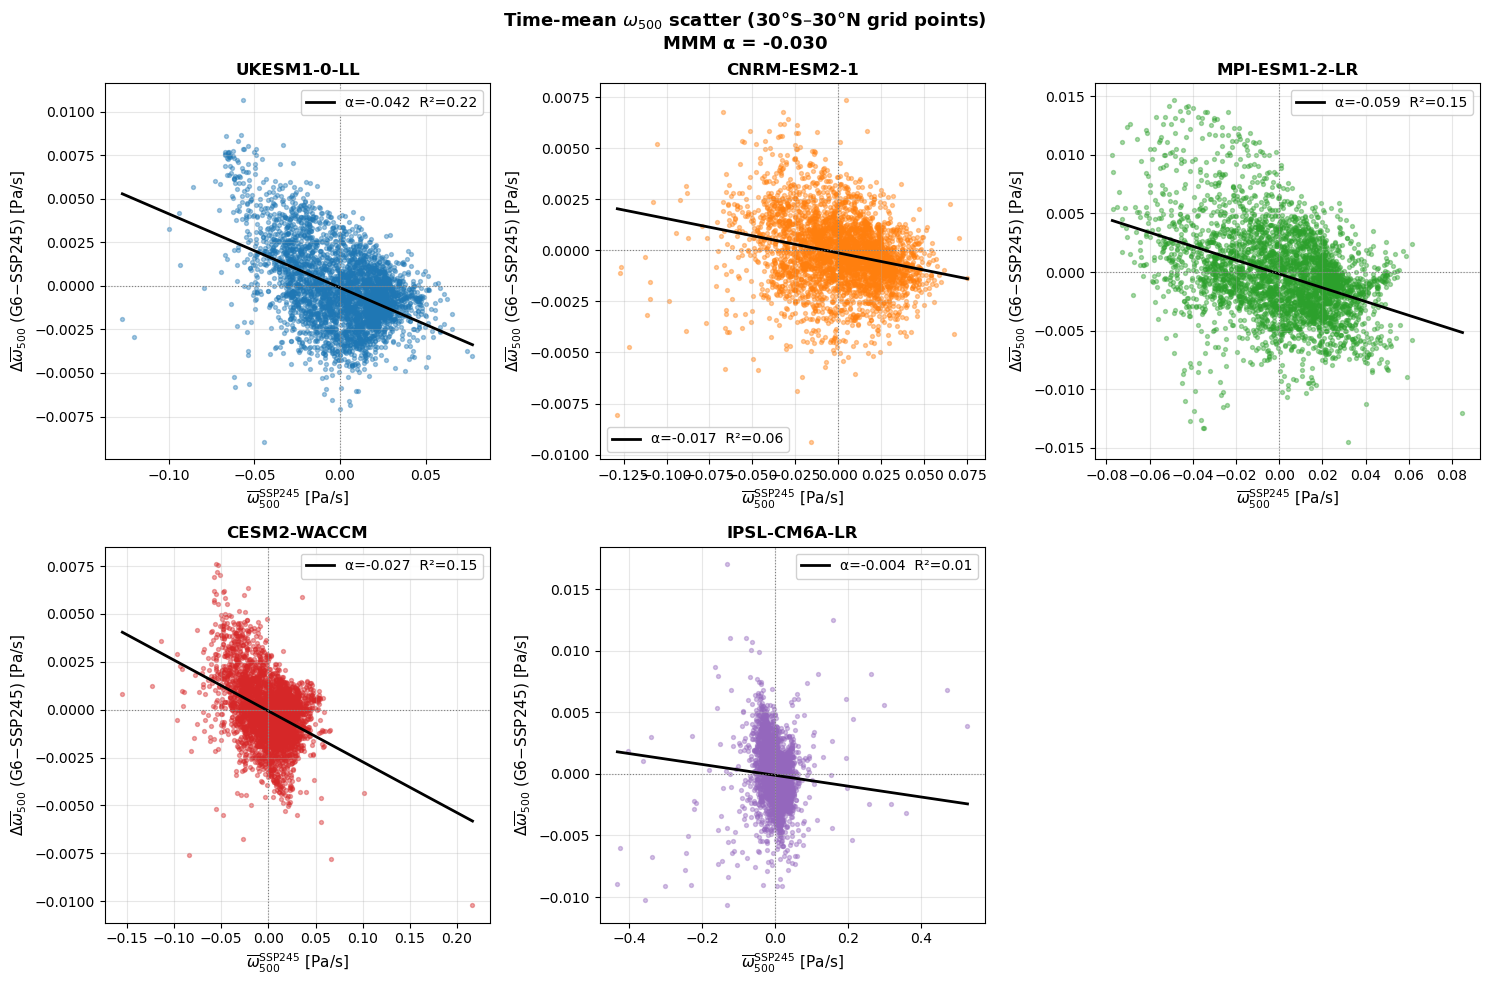


MMM α = -0.0298
  UKESM1-0-LL:  α=-0.0423   R²=0.222
  CNRM-ESM2-1:  α=-0.0168   R²=0.062
  MPI-ESM1-2-LR:  α=-0.0590   R²=0.153
  CESM2-WACCM:  α=-0.0266   R²=0.152
  IPSL-CM6A-LR:  α=-0.0044   R²=0.006


In [6]:
# ================================================================
# COMPUTE w500 time-mean spatial fields and alpha
# x = w500_ssp_timemean (lat, lon)
# y = w500_g6_timemean - w500_ssp_timemean (lat, lon)
# alpha = slope of scatter (delta / ssp)
# ================================================================

from scipy import stats

all_results = {}

for model_name, model_meta in MODELS.items():

    omega_store_model = {}

    for exp, meta in EXPERIMENTS.items():

        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_wap = make_base("wap")
        ds_wap   = load_model_data_alt_path(base_wap, meta["project"],
                                            model_meta["institution"],
                                            model_name, meta["scenario"],
                                            ensemble, model_meta["grid"], mf, "wap")

        t_start, t_end = _time_slice(exp)
        ds_wap = ds_wap.sel(time=slice(t_start, t_end))
        ds_wap = roll_and_regrid(ds_wap)

        print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
              f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

        if isinstance(ds_wap, xr.Dataset):
            omega = ds_wap['wap']
        else:
            omega = ds_wap

        # Select 500 hPa and tropical region
        omega_500  = omega.sel(plev=target_plev, method='nearest')
        omega_trop = omega_500.sel(lat=slice(trop_lat_min, trop_lat_max))

        # Time mean → spatial field (lat, lon)
        omega_timemean = omega_trop.mean(dim='time')

        omega_store_model[exp] = omega_timemean   # (lat, lon)

    # --- Spatial fields ---
    w500_ssp = omega_store_model[EXP2]                  # (lat, lon)
    w500_g6  = omega_store_model[EXP1]                  # (lat, lon)
    delta_w500 = w500_g6 - w500_ssp                     # (lat, lon)

    # --- Flatten for scatter and alpha ---
    x = w500_ssp.values.flatten()
    y = delta_w500.values.flatten()

    valid        = np.isfinite(x) & np.isfinite(y)
    x_clean      = x[valid]
    y_clean      = y[valid]

    slope, intercept, r_value, p_value, _ = stats.linregress(x_clean, y_clean)
    alpha = slope

    all_results[model_name] = {
        'w500_ssp':    w500_ssp,       # (lat, lon) xarray — time mean SSP245
        'w500_g6':     w500_g6,        # (lat, lon) xarray — time mean G6
        'delta_w500':  delta_w500,     # (lat, lon) xarray — G6 minus SSP245
        'x':           x_clean,        # flattened, for scatter
        'y':           y_clean,        # flattened, for scatter
        'alpha':       alpha,           # OLS slope
        'intercept':   intercept,
        'r2':          r_value**2,
    }

    print(f"  [{model_name}] alpha(OLS)={alpha:.4f}  R²={r_value**2:.3f}  "
          f"n_points={valid.sum()}")

print("\nDone. all_results keys:", list(all_results.keys()))

# ================================================================
# PLOT — one panel per model
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes      = axes.flatten()
colors    = {name: plt.cm.tab10(i) for i, name in enumerate(all_results.keys())}

for idx, (model_name, res) in enumerate(all_results.items()):
    ax    = axes[idx]
    color = colors[model_name]

    x     = res['x']
    y     = res['y']
    alpha = res['alpha']
    r2    = res['r2']

    ax.scatter(x, y, s=8, alpha=0.4, color=color)

    # OLS regression line
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, res['alpha'] * x_line + res['intercept'],
            color='black', linewidth=2,
            label=f'α={alpha:.3f}  R²={r2:.2f}')

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)

    ax.set_xlabel(r'$\overline{\omega}_{500}^{\mathrm{SSP245}}$ [Pa/s]', fontsize=11)
    ax.set_ylabel(r'$\Delta\overline{\omega}_{500}$ (G6−SSP245) [Pa/s]',  fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)

for idx in range(len(all_results), 6):
    axes[idx].axis('off')

alpha_mmm = np.mean([res['alpha'] for res in all_results.values()])
fig.suptitle(rf'Time-mean $\omega_{{500}}$ scatter (30°S–30°N grid points)'
             f'\nMMM α = {alpha_mmm:.3f}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('scatter_alpha_w500_spatial.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMMM α = {alpha_mmm:.4f}")
for m, res in all_results.items():
    print(f"  {m}:  α={res['alpha']:.4f}   R²={res['r2']:.3f}")